In [2]:
import pandas as pd

df = pd.read_csv("breast_cancer.data")
df.columns = ['id', 'clump_thickness', 'cell_size', 'cell_shape', 'marginal_adhesion', 
        'epithelial_size', 'bare_nuclei', 'bland_chromatin', 'normal_nucleoli', 
        'mitoses', 'class']

print(df.shape)
print(df.info())


(698, 11)
<class 'pandas.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 698 non-null    int64
 1   clump_thickness    698 non-null    int64
 2   cell_size          698 non-null    int64
 3   cell_shape         698 non-null    int64
 4   marginal_adhesion  698 non-null    int64
 5   epithelial_size    698 non-null    int64
 6   bare_nuclei        698 non-null    str  
 7   bland_chromatin    698 non-null    int64
 8   normal_nucleoli    698 non-null    int64
 9   mitoses            698 non-null    int64
 10  class              698 non-null    int64
dtypes: int64(10), str(1)
memory usage: 60.1 KB
None


In [5]:
for col in df.columns:
    print(df[col].value_counts())

id
1182404    6
1276091    5
1198641    3
1017023    2
1033078    2
          ..
714039     1
763235     1
776715     1
841769     1
888820     1
Name: count, Length: 644, dtype: int64
clump_thickness
1     145
5     129
3     108
4      80
10     69
2      50
8      46
6      34
7      23
9      14
Name: count, dtype: int64
cell_size
1     383
10     67
3      52
2      45
4      40
5      30
8      29
6      27
7      19
9       6
Name: count, dtype: int64
cell_shape
1     352
2      59
10     58
3      56
4      44
5      34
6      30
7      30
8      28
9       7
Name: count, dtype: int64
marginal_adhesion
1     406
3      58
2      58
10     55
4      33
8      25
5      23
6      22
7      13
9       5
Name: count, dtype: int64
epithelial_size
2     385
3      72
4      48
1      47
6      41
5      39
10     31
8      21
7      12
9       2
Name: count, dtype: int64
bare_nuclei
1     401
10    132
2      30
5      30
3      28
8      21
4      19
9       9
7       8
6       4
Na

In [4]:
import numpy as np

df = df.replace('?', np.nan)


In [ ]:
print(df.isnull().sum())

id                    0
clump_thickness       0
cell_size             0
cell_shape            0
marginal_adhesion     0
epithelial_size       0
bare_nuclei          16
bland_chromatin       0
normal_nucleoli       0
mitoses               0
class                 0
dtype: int64


In [7]:
print(df['bare_nuclei'].unique())

<StringArray>
['10', '2', '4', '1', '3', '9', '7', nan, '5', '8', '6']
Length: 11, dtype: str


In [13]:
df['bare_nuclei'] = df['bare_nuclei'].astype(float)

In [16]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   clump_thickness    698 non-null    int64  
 1   cell_size          698 non-null    int64  
 2   cell_shape         698 non-null    int64  
 3   marginal_adhesion  698 non-null    int64  
 4   epithelial_size    698 non-null    int64  
 5   bare_nuclei        682 non-null    float64
 6   bland_chromatin    698 non-null    int64  
 7   normal_nucleoli    698 non-null    int64  
 8   mitoses            698 non-null    int64  
 9   class              698 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB
None


In [14]:
df = df.drop(columns = ['id'])

In [15]:
df['class'] = df['class'].map({2: 0, 4: 1})

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = ['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
cols = X.select_dtypes(include = ['int64', 'float64']).columns.tolist()

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler    

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


In [23]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, cols)
])

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'), 
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced')
}

fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    test_acc = accuracy_score(y_test, pipe.predict(X_test))
    print(f"{name} - Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")

Logistic Regression - Train Accuracy: 0.9659, Test Accuracy: 0.9786
Decision Tree - Train Accuracy: 1.0000, Test Accuracy: 0.9429
Random Forest - Train Accuracy: 1.0000, Test Accuracy: 0.9786


In [27]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1')
    print(f"{name} - Cross-Validation f1: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression - Cross-Validation f1: 0.9487 ± 0.0116
Decision Tree - Cross-Validation f1: 0.8784 ± 0.0393
Random Forest - Cross-Validation f1: 0.9435 ± 0.0176


In [31]:
final_pipeline = fitted_pipelines["Logistic Regression"]
final_pipeline.fit(X_train, y_train)
print(accuracy_score(y_test, final_pipeline.predict(X_test)))

0.9785714285714285


In [34]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, final_pipeline.predict(X_test)))


              precision    recall  f1-score   support

           0       0.97      1.00      0.98        92
           1       1.00      0.94      0.97        48

    accuracy                           0.98       140
   macro avg       0.98      0.97      0.98       140
weighted avg       0.98      0.98      0.98       140



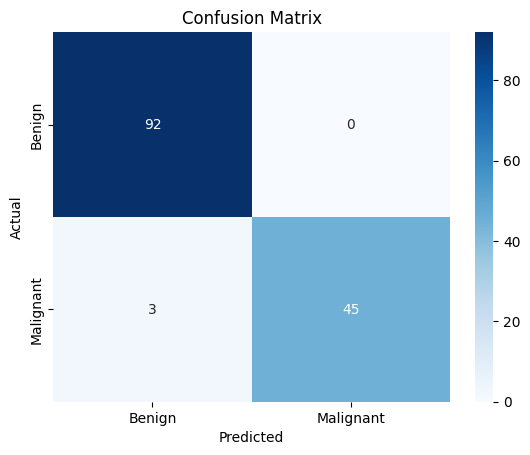

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, final_pipeline.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')   
plt.title('Confusion Matrix')
plt.show()